# Data Exploration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import wavfile
import librosa
import librosa.display
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 10

PROJECT_ROOT = Path(r"D:\sop")
DATA_ABSENT = PROJECT_ROOT / "absent 2391"
DATA_PRESENT = PROJECT_ROOT / "present_2391"
DATA_UNKNOWN = PROJECT_ROOT / "unknown_2391"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

print("Ready.")

Ready.


## Scanning all WAV files

In [2]:
# collecting file information from each class folder

def get_file_info(file_path, class_name, label):
    """Reads a WAV file and returns its properties."""
    name = file_path.stem
    is_augmented = '_gauss' in name
    base = name.split('_gauss')[0] if is_augmented else name
    parts = base.split('_')
    prefix = parts[0][0] if parts else None
    patient_id = parts[0][1:] if parts else None
    location = parts[1] if len(parts) >= 2 else None

    try:
        sr, data = wavfile.read(file_path)
        data_float = data.astype(np.float32) / 32768.0 if data.dtype == np.int16 else data.astype(np.float32)
        return {
            'file': file_path.name, 'path': str(file_path),
            'class': class_name, 'label': label,
            'patient_id': patient_id, 'location': location,
            'is_augmented': is_augmented,
            'sr': sr, 'samples': len(data),
            'duration': len(data) / sr,
            'channels': 1 if len(data.shape) == 1 else data.shape[1],
            'rms': float(np.sqrt(np.mean(data_float**2))),
            'min_amp': float(data_float.min()),
            'max_amp': float(data_float.max()),
            'error': None
        }
    except Exception as e:
        return {'file': file_path.name, 'path': str(file_path),
                'class': class_name, 'label': label,
                'patient_id': patient_id, 'location': location,
                'is_augmented': is_augmented,
                'sr': None, 'samples': None, 'duration': None,
                'channels': None, 'rms': None,
                'min_amp': None, 'max_amp': None,
                'error': str(e)}

In [3]:
# scanning all three folders

all_records = []

folders = [
    (DATA_ABSENT, 'absent', 0),
    (DATA_PRESENT, 'present', 1),
    (DATA_UNKNOWN, 'unknown', -1),
]

for folder, class_name, label in folders:
    files = sorted(folder.glob('*.wav'))
    print(f"{class_name}: {len(files)} files")
    for f in files:
        all_records.append(get_file_info(f, class_name, label))

df = pd.DataFrame(all_records)
print(f"\nTotal: {len(df)} files scanned")

absent: 2391 files
present: 2391 files
unknown: 2391 files

Total: 7173 files scanned


In [4]:
# checking for errors or corrupted files

errors = df[df['error'].notna()]
if len(errors) > 0:
    print(f"{len(errors)} files had errors:")
    print(errors[['file', 'class', 'error']])
else:
    print("No errors. All files loaded cleanly.")

df = df[df['error'].isna()].copy()

No errors. All files loaded cleanly.


In [5]:
# looking at the collected data

df.head(10)

,file,path,class,label,patient_id,location,is_augmented,sr,samples,duration,channels,rms,min_amp,max_amp,error
0,a100_AV.wav,D:\sop\absent 2391\a100_AV.wav,absent,0,100,AV,False,4000,121024,30.256,1,0.061858,-0.996613,0.999969,None
1,a100_MV.wav,D:\sop\absent 2391\a100_MV.wav,absent,0,100,MV,False,4000,124352,31.088,1,0.045504,-0.946899,0.999969,None
2,a101_AV.wav,D:\sop\absent 2391\a101_AV.wav,absent,0,101,AV,False,4000,123712,30.928,1,0.040162,-1.000000,0.999969,None
3,a101_MV.wav,D:\sop\absent 2391\a101_MV.wav,absent,0,101,MV,False,4000,123584,30.896,1,0.031621,-1.000000,0.999969,None
4,a101_PV.wav,D:\sop\absent 2391\a101_PV.wav,absent,0,101,PV,False,4000,119040,29.760,1,0.047562,-1.000000,0.999969,None
5,a101_TV.wav,D:\sop\absent 2391\a101_TV.wav,absent,0,101,TV,False,4000,120192,30.048,1,0.026363,-0.935516,0.950500,None
6,a102_AV.wav,D:\sop\absent 2391\a102_AV.wav,absent,0,102,AV,False,4000,119552,29.888,1,0.047839,-1.000000,0.999969,None
7,a102_MV.wav,D:\sop\absent 2391\a102_MV.wav,absent,0,102,MV,False,4000,111168,27.792,1,0.016732,-1.000000,0.696136,None
8,a102_PV.wav,D:\sop\absent 2391\a102_PV.wav,absent,0,102,PV,False,4000,89600,22.400,1,0.030565,-1.000000,0.999969,None
9,a102_TV.wav,D:\sop\absent 2391\a102_TV.wav,absent,0,102,TV,False,4000,80512,20.128,1,0.031587,-1.000000,0.999969,None


## File counts and class balance

In [6]:
# counting files per class

counts = df['class'].value_counts().reindex(['absent', 'present', 'unknown'])

for cls, n in counts.items():
    print(f"{cls:>10}: {n} files")

print(f"\n     Total: {len(df)} files")
print(f"  Training: {len(df[df['class'] != 'unknown'])} (absent + present)")
print(f" Inference: {len(df[df['class'] == 'unknown'])} (unknown)")

    absent: 2391 files
   present: 2391 files
   unknown: 2391 files

     Total: 7173 files
  Training: 4782 (absent + present)
 Inference: 2391 (unknown)


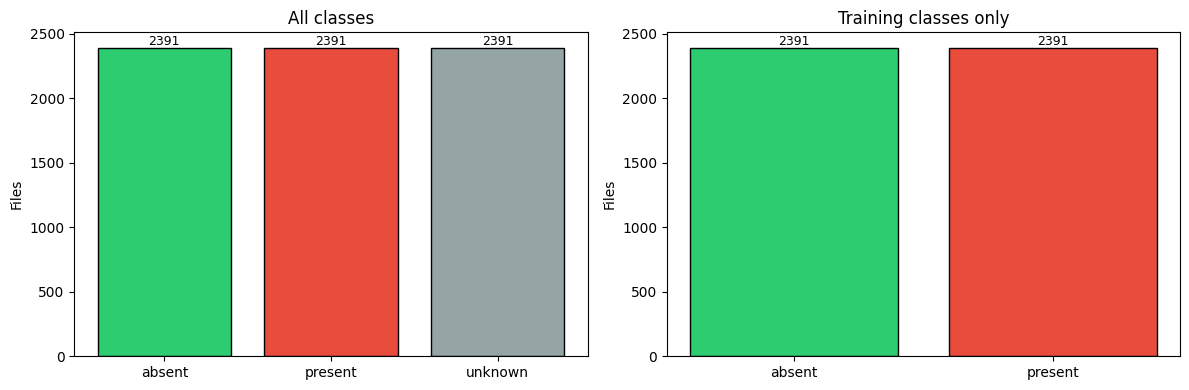

In [7]:
# visualising class distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors_map = {'absent': '#2ecc71', 'present': '#e74c3c', 'unknown': '#95a5a6'}

axes[0].bar(counts.index, counts.values, color=[colors_map[c] for c in counts.index], edgecolor='black')
axes[0].set_title('All classes')
axes[0].set_ylabel('Files')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=9)

train = counts.drop('unknown')
axes[1].bar(train.index, train.values, color=[colors_map[c] for c in train.index], edgecolor='black')
axes[1].set_title('Training classes only')
axes[1].set_ylabel('Files')
for i, v in enumerate(train.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Original vs Gaussian noise augmented files

In [8]:
# breaking down original and augmented file counts per class

aug_breakdown = df.groupby(['class', 'is_augmented']).size().unstack(fill_value=0)
aug_breakdown.columns = ['Original', 'Augmented (gaussian noise)']
aug_breakdown['Total'] = aug_breakdown.sum(axis=1)
print(aug_breakdown)

total_orig = (~df['is_augmented']).sum()
total_aug = df['is_augmented'].sum()
print(f"\nOverall: {total_orig} original, {total_aug} augmented")

         Original  Augmented (gaussian noise)  Total
class                                               
absent       2391                           0   2391
present       616                        1775   2391
unknown       156                        2235   2391

Overall: 3163 original, 4010 augmented


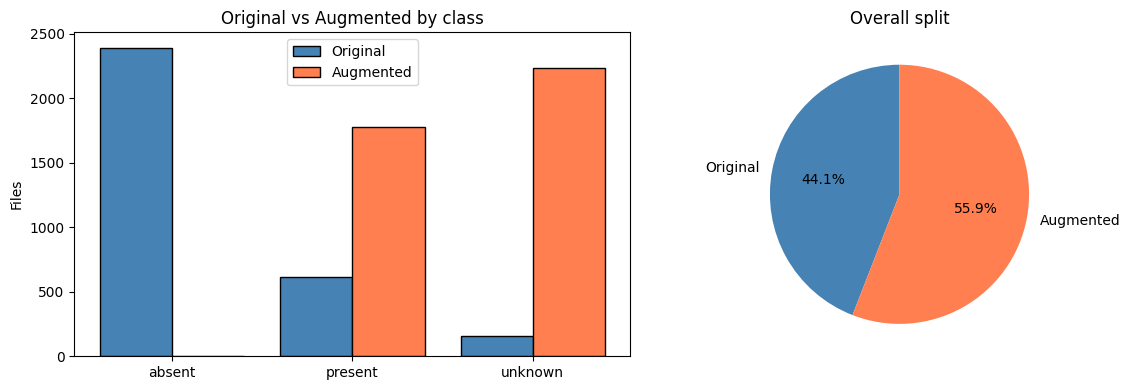

In [9]:
# visualising original vs augmented split

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

classes = ['absent', 'present', 'unknown']
orig = [len(df[(df['class']==c) & (~df['is_augmented'])]) for c in classes]
aug = [len(df[(df['class']==c) & (df['is_augmented'])]) for c in classes]

x = np.arange(len(classes))
axes[0].bar(x, orig, 0.4, label='Original', color='steelblue', edgecolor='black')
axes[0].bar(x + 0.4, aug, 0.4, label='Augmented', color='coral', edgecolor='black')
axes[0].set_xticks(x + 0.2)
axes[0].set_xticklabels(classes)
axes[0].set_ylabel('Files')
axes[0].set_title('Original vs Augmented by class')
axes[0].legend()

axes[1].pie([total_orig, total_aug], labels=['Original', 'Augmented'],
            autopct='%1.1f%%', colors=['steelblue', 'coral'], startangle=90)
axes[1].set_title('Overall split')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'augmentation_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# comparing an original file with its augmented versions

sample_patient = df[(df['class']=='present') & (~df['is_augmented'])].iloc[0]
base_name = sample_patient['file'].replace('.wav', '')
augmented_versions = df[(df['class']=='present') & (df['file'].str.startswith(base_name + '_gauss'))]

print(f"Original: {sample_patient['file']}")
print(f"Augmented versions found: {len(augmented_versions)}")
for _, row in augmented_versions.iterrows():
    print(f"  {row['file']}")

Original: p100_AV.wav
Augmented versions found: 3
  p100_AV_gauss1.wav
  p100_AV_gauss1233.wav
  p100_AV_gauss617.wav


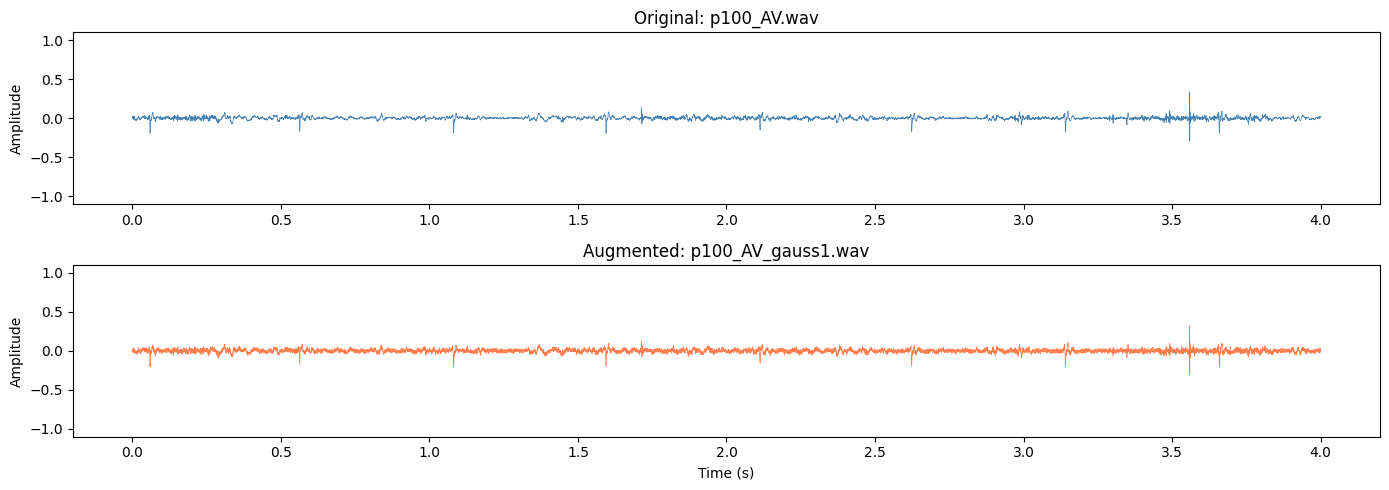

In [11]:
# plotting original vs one augmented version side by side

if len(augmented_versions) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(14, 5))

    orig_data, sr = librosa.load(sample_patient['path'], sr=None)
    aug_path = augmented_versions.iloc[0]['path']
    aug_data, _ = librosa.load(aug_path, sr=None)

    # showing first 4 seconds for clarity
    n = int(4 * sr)
    t = np.arange(min(n, len(orig_data))) / sr

    axes[0].plot(t, orig_data[:len(t)], color='steelblue', linewidth=0.5)
    axes[0].set_title(f'Original: {sample_patient["file"]}')
    axes[0].set_ylabel('Amplitude')
    axes[0].set_ylim(-1.1, 1.1)

    axes[1].plot(t, aug_data[:len(t)], color='coral', linewidth=0.5)
    axes[1].set_title(f'Augmented: {augmented_versions.iloc[0]["file"]}')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Amplitude')
    axes[1].set_ylim(-1.1, 1.1)

    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'original_vs_augmented.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No augmented versions found for this sample.")

## Sampling rate

In [12]:
# checking if all files share the same sampling rate

unique_sr = df['sr'].unique()
print(f"Unique sampling rates: {unique_sr}")

if len(unique_sr) == 1:
    print(f"All files are at {unique_sr[0]} Hz. No resampling needed.")
else:
    print("Multiple sampling rates found. Will need resampling in preprocessing.")
    print(df['sr'].value_counts())

Unique sampling rates: [4000]
All files are at 4000 Hz. No resampling needed.


## Duration analysis

In [13]:
# summarising signal durations per class

dur_stats = df.groupby('class')['duration'].describe()[['count','min','max','mean','std','50%']]
dur_stats.columns = ['count','min','max','mean','std','median']
print(dur_stats.round(2))

print(f"\nShortest signal: {df['duration'].min():.2f} s")
print(f"Longest signal:  {df['duration'].max():.2f} s")
print(f"Average:         {df['duration'].mean():.2f} s")

          count   min    max   mean   std  median
class                                            
absent   2391.0  5.15  58.75  23.05  7.12   21.66
present  2391.0  6.38  64.51  22.42  7.93   21.09
unknown  2391.0  7.55  43.89  22.37  6.98   21.09

Shortest signal: 5.15 s
Longest signal:  64.51 s
Average:         22.62 s


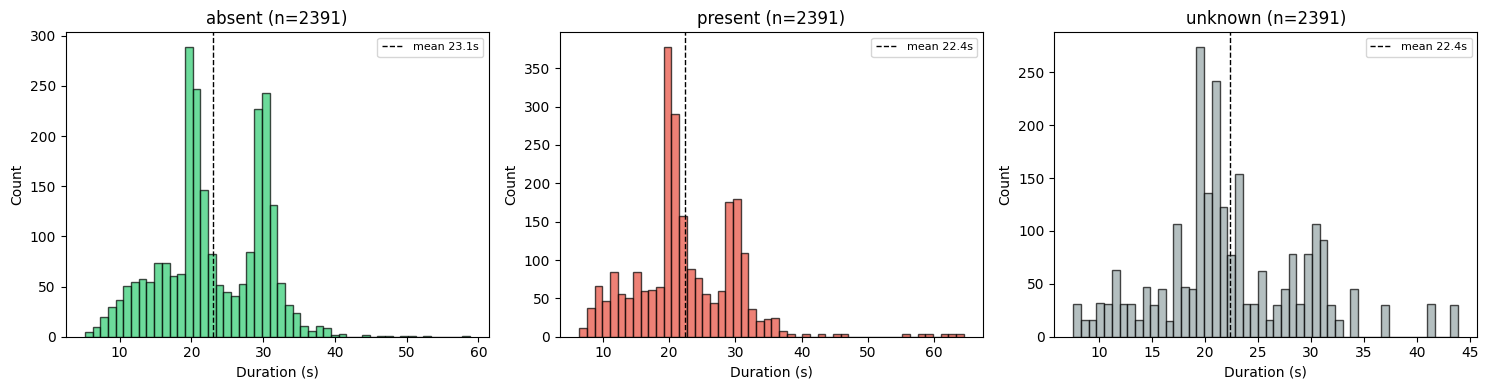

In [14]:
# comparing duration distributions across classes

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, cls in enumerate(['absent', 'present', 'unknown']):
    d = df[df['class'] == cls]['duration']
    axes[i].hist(d, bins=50, color=colors_map[cls], edgecolor='black', alpha=0.7)
    axes[i].axvline(d.mean(), color='black', linestyle='--', linewidth=1, label=f'mean {d.mean():.1f}s')
    axes[i].set_title(f'{cls} (n={len(d)})')
    axes[i].set_xlabel('Duration (s)')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'duration_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# checking if augmented files have different durations than originals

for cls in ['present', 'unknown']:
    orig_dur = df[(df['class']==cls) & (~df['is_augmented'])]['duration']
    aug_dur = df[(df['class']==cls) & (df['is_augmented'])]['duration']
    if len(aug_dur) > 0:
        print(f"{cls}: original mean {orig_dur.mean():.2f}s, augmented mean {aug_dur.mean():.2f}s")

present: original mean 22.29s, augmented mean 22.47s
unknown: original mean 22.40s, augmented mean 22.37s


## Auscultation locations

In [16]:
# counting files by recording location (AV, MV, PV, TV)

loc_counts = df.groupby(['class', 'location']).size().unstack(fill_value=0)
print(loc_counts)

print("\nLocation key:")
print("  AV = Aortic Valve")
print("  MV = Mitral Valve")
print("  PV = Pulmonary Valve")
print("  TV = Tricuspid Valve")

location   AV   MV   PV  Phc   TV
class                            
absent    603  637  586    2  563
present   589  668  571    8  555
unknown   689  797  505    0  400

Location key:
  AV = Aortic Valve
  MV = Mitral Valve
  PV = Pulmonary Valve
  TV = Tricuspid Valve


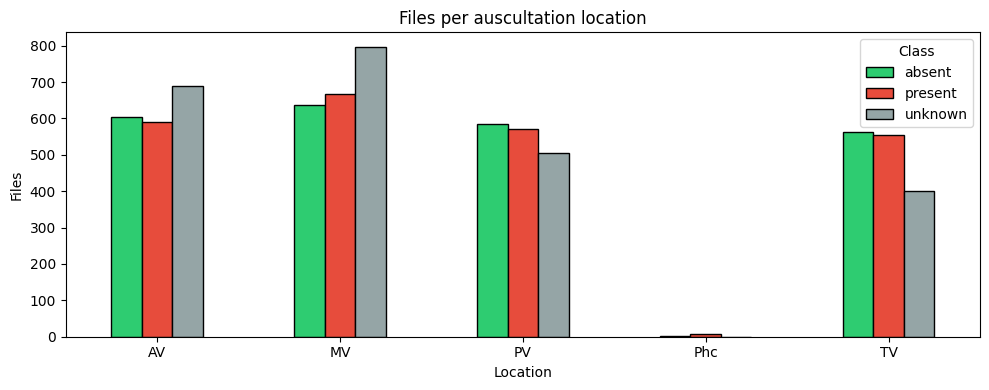

In [17]:
# plotting location distribution

fig, ax = plt.subplots(figsize=(10, 4))
loc_counts.T.plot(kind='bar', ax=ax, color=[colors_map.get(c, 'gray') for c in loc_counts.index],
                  edgecolor='black')
ax.set_xlabel('Location')
ax.set_ylabel('Files')
ax.set_title('Files per auscultation location')
ax.legend(title='Class')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'location_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Patient analysis

In [18]:
# counting unique patients and files per patient

for cls in ['absent', 'present', 'unknown']:
    subset = df[df['class'] == cls]
    n_patients = subset['patient_id'].nunique()
    n_files = len(subset)
    print(f"{cls:>10}: {n_patients} patients, {n_files} files, ~{n_files/n_patients:.1f} files/patient")

    absent: 695 patients, 2391 files, ~3.4 files/patient
   present: 179 patients, 2391 files, ~13.4 files/patient
   unknown: 68 patients, 2391 files, ~35.2 files/patient


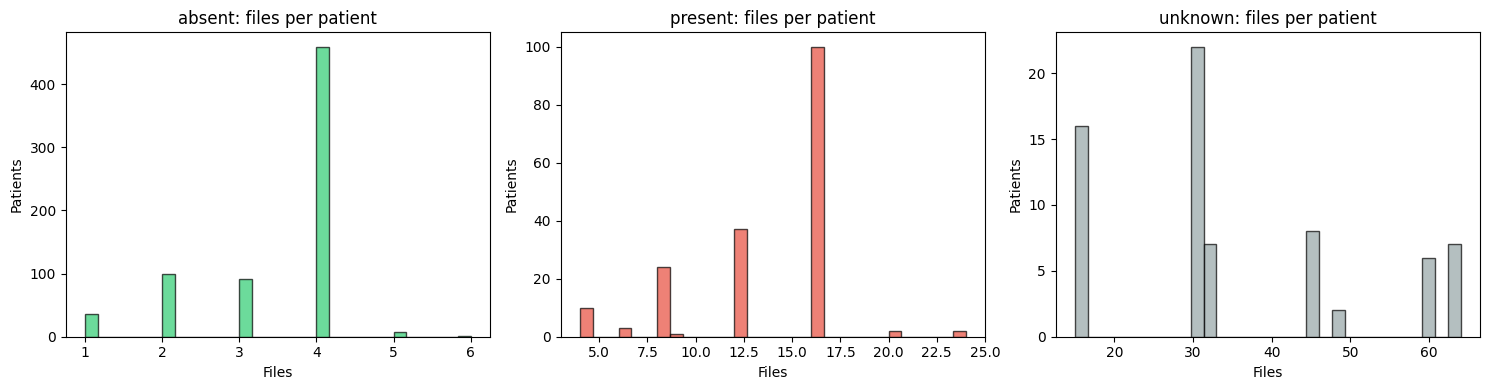

In [19]:
# files per patient distribution

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, cls in enumerate(['absent', 'present', 'unknown']):
    patient_counts = df[df['class'] == cls].groupby('patient_id').size()
    axes[i].hist(patient_counts, bins=30, color=colors_map[cls], edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{cls}: files per patient')
    axes[i].set_xlabel('Files')
    axes[i].set_ylabel('Patients')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'files_per_patient.png', dpi=150, bbox_inches='tight')
plt.show()

## Sample waveforms

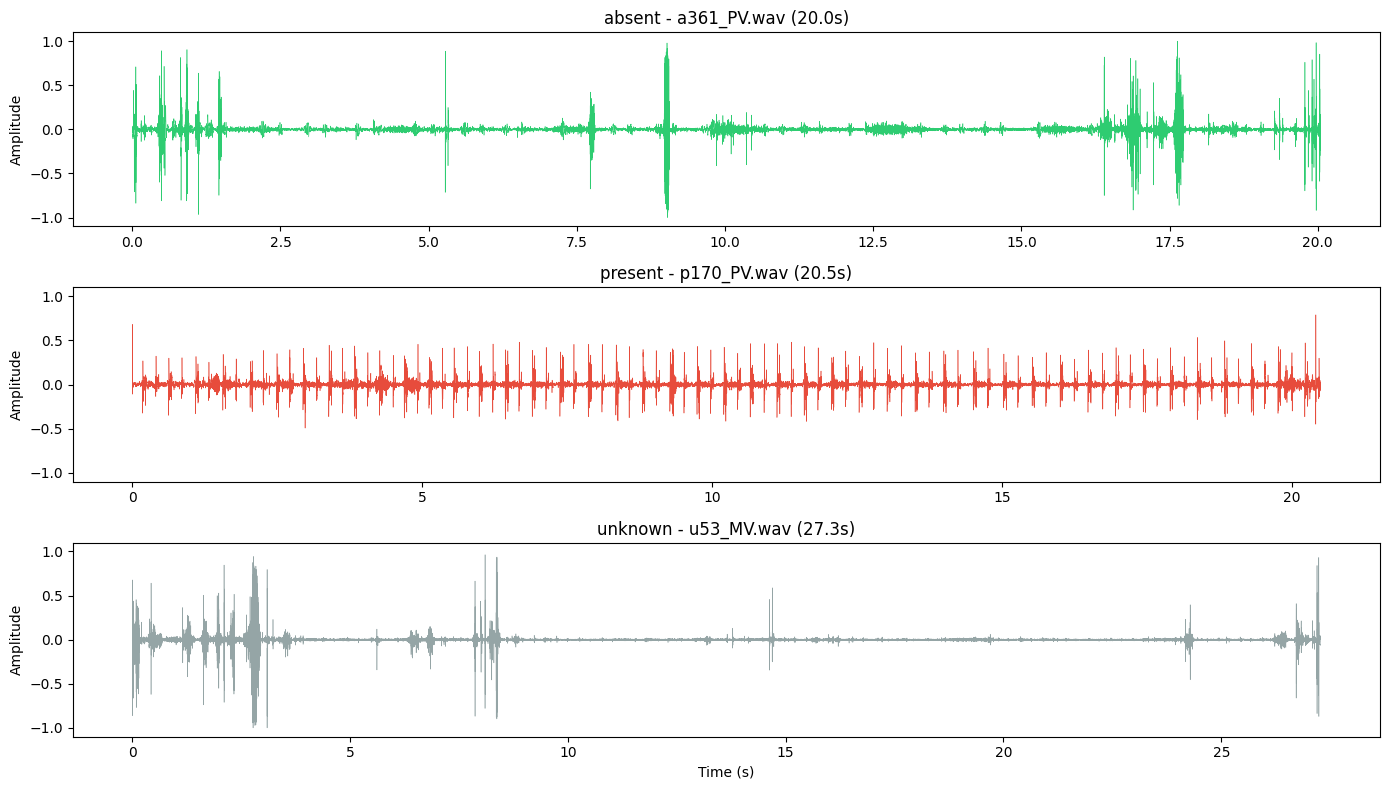

In [20]:
# plotting one waveform from each class (original files only)

np.random.seed(42)
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=False)

for i, (cls, color) in enumerate([('absent','#2ecc71'), ('present','#e74c3c'), ('unknown','#95a5a6')]):
    sample = df[(df['class']==cls) & (~df['is_augmented'])].sample(1).iloc[0]
    data, sr = librosa.load(sample['path'], sr=None)
    t = np.arange(len(data)) / sr

    axes[i].plot(t, data, color=color, linewidth=0.4)
    axes[i].set_title(f"{cls} - {sample['file']} ({sample['duration']:.1f}s)")
    axes[i].set_ylabel('Amplitude')
    axes[i].set_ylim(-1.1, 1.1)

axes[2].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'sample_waveforms.png', dpi=150, bbox_inches='tight')
plt.show()

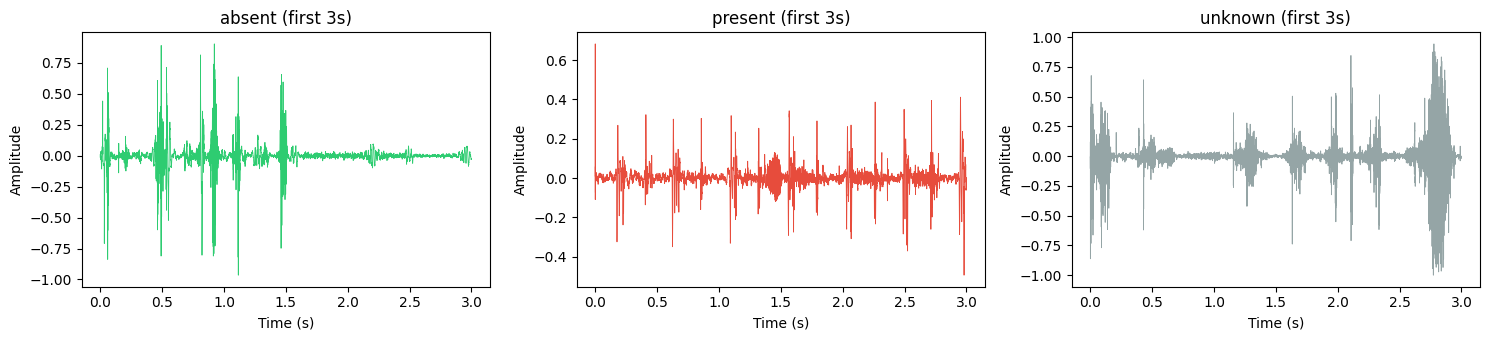

In [21]:
# zoomed view of the first 3 seconds from each class

np.random.seed(42)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

for i, (cls, color) in enumerate([('absent','#2ecc71'), ('present','#e74c3c'), ('unknown','#95a5a6')]):
    sample = df[(df['class']==cls) & (~df['is_augmented'])].sample(1).iloc[0]
    data, sr = librosa.load(sample['path'], sr=None)
    n = int(3 * sr)
    t = np.arange(n) / sr

    axes[i].plot(t, data[:n], color=color, linewidth=0.6)
    axes[i].set_title(f'{cls} (first 3s)')
    axes[i].set_xlabel('Time (s)')
    axes[i].set_ylabel('Amplitude')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'waveforms_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()

## Spectrograms

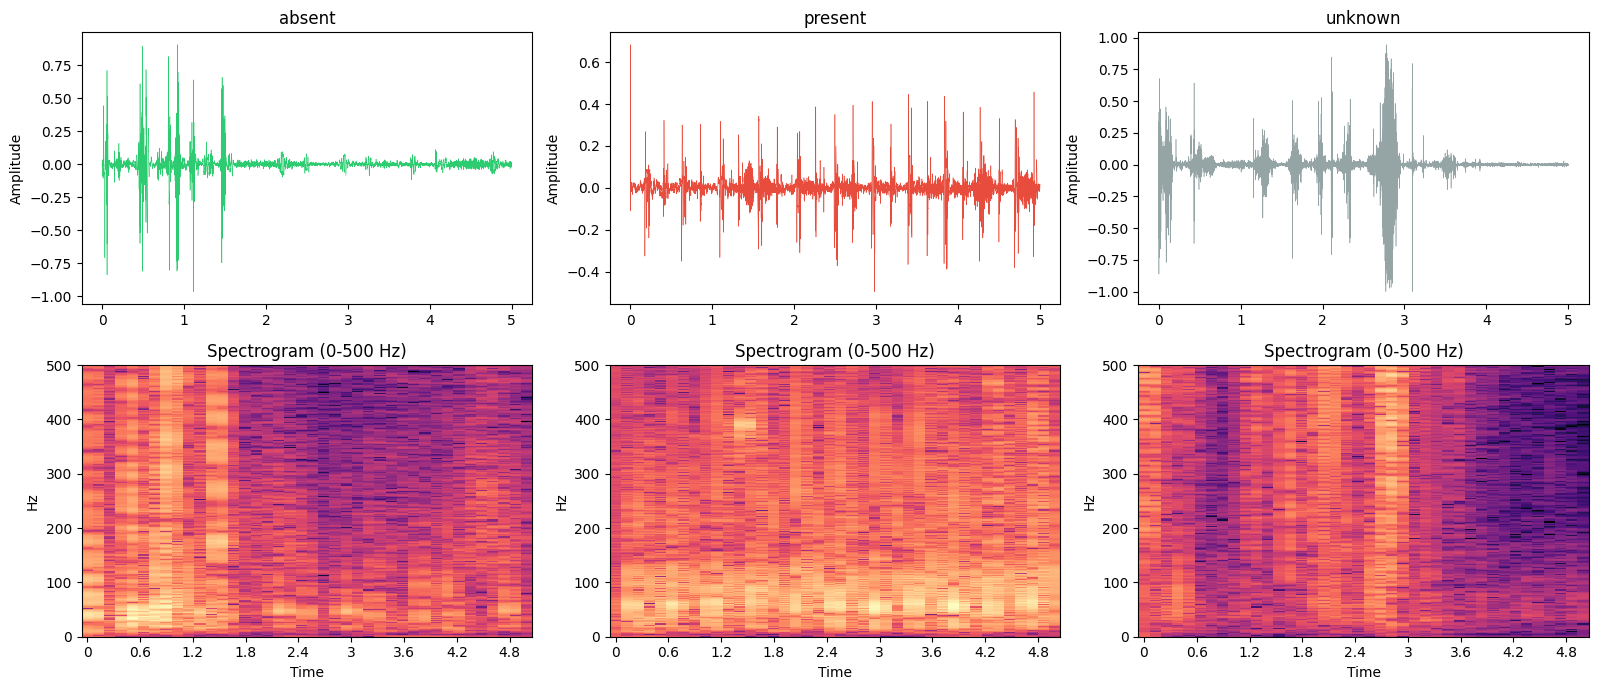

In [22]:
# comparing spectrograms across classes (first 5 seconds, 0-500 Hz range)

np.random.seed(42)
fig, axes = plt.subplots(2, 3, figsize=(16, 7))

for i, (cls, color) in enumerate([('absent','#2ecc71'), ('present','#e74c3c'), ('unknown','#95a5a6')]):
    sample = df[(df['class']==cls) & (~df['is_augmented'])].sample(1).iloc[0]
    data, sr = librosa.load(sample['path'], sr=None)
    data = data[:int(5 * sr)]
    t = np.arange(len(data)) / sr

    axes[0, i].plot(t, data, color=color, linewidth=0.4)
    axes[0, i].set_title(f'{cls}')
    axes[0, i].set_ylabel('Amplitude')

    S = librosa.amplitude_to_db(np.abs(librosa.stft(data)), ref=np.max)
    librosa.display.specshow(S, sr=sr, x_axis='time', y_axis='hz', ax=axes[1, i], cmap='magma')
    axes[1, i].set_ylim(0, 500)
    axes[1, i].set_title('Spectrogram (0-500 Hz)')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'spectrograms.png', dpi=150, bbox_inches='tight')
plt.show()

## Amplitude and energy

In [23]:
# summarising amplitude and RMS energy

amp_stats = df.groupby('class')[['min_amp','max_amp','rms']].agg(['mean','std']).round(4)
print(amp_stats)

        min_amp         max_amp             rms        
           mean     std    mean     std    mean     std
class                                                  
absent  -0.9122  0.1479  0.9479  0.1023  0.0453  0.0332
present -0.8946  0.1510  0.9441  0.0974  0.0591  0.0451
unknown -0.9428  0.1039  0.9632  0.0749  0.0788  0.0805


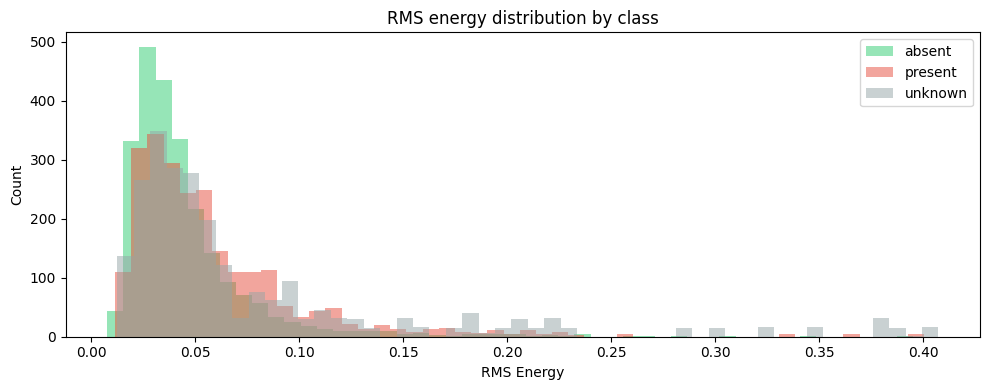

In [24]:
# comparing RMS distributions

fig, ax = plt.subplots(figsize=(10, 4))

for cls in ['absent', 'present', 'unknown']:
    rms = df[df['class'] == cls]['rms']
    ax.hist(rms, bins=50, alpha=0.5, label=cls, color=colors_map[cls])

ax.set_xlabel('RMS Energy')
ax.set_ylabel('Count')
ax.set_title('RMS energy distribution by class')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'rms_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# comparing RMS between original and augmented files

for cls in ['present', 'unknown']:
    orig_rms = df[(df['class']==cls) & (~df['is_augmented'])]['rms']
    aug_rms = df[(df['class']==cls) & (df['is_augmented'])]['rms']
    if len(aug_rms) > 0:
        print(f"{cls}: original RMS mean {orig_rms.mean():.4f}, augmented RMS mean {aug_rms.mean():.4f}")

present: original RMS mean 0.0588, augmented RMS mean 0.0592
unknown: original RMS mean 0.0783, augmented RMS mean 0.0789


## Saving metadata

In [26]:
# saving the full metadata to CSV for use in later notebooks

metadata_path = PROJECT_ROOT / 'data' / 'file_metadata.csv'
df.to_csv(metadata_path, index=False)
print(f"Metadata saved: {metadata_path}")
print(f"{len(df)} rows, {len(df.columns)} columns")
print(f"Columns: {list(df.columns)}")

Metadata saved: D:\sop\data\file_metadata.csv
7173 rows, 15 columns
Columns: ['file', 'path', 'class', 'label', 'patient_id', 'location', 'is_augmented', 'sr', 'samples', 'duration', 'channels', 'rms', 'min_amp', 'max_amp', 'error']


In [27]:
# quick summary

print("Key findings:")
print(f"  All files at {df['sr'].iloc[0]} Hz, no resampling needed")
print(f"  Durations range from {df['duration'].min():.1f}s to {df['duration'].max():.1f}s")
print(f"  {total_orig} original files, {total_aug} gaussian-augmented files")
print(f"  Absent has no augmentation, Present and Unknown have augmented copies")
print(f"  4 auscultation locations: AV, MV, PV, TV")
print(f"  Data is clean, no errors found")

Key findings:
  All files at 4000 Hz, no resampling needed
  Durations range from 5.2s to 64.5s
  3163 original files, 4010 gaussian-augmented files
  Absent has no augmentation, Present and Unknown have augmented copies
  4 auscultation locations: AV, MV, PV, TV
  Data is clean, no errors found
